In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

project_path = "/content/drive/MyDrive/NLP_Project"

os.chdir(project_path)

print("Current directory:", os.getcwd())

Current directory: /content/drive/MyDrive/NLP_Project


# Install Required Libraries

In [3]:
!pip install -q camel-tools transformers datasets sentencepiece \
arabic-reshaper python-bidi wordcloud pyarabic emoji \
openai tqdm

In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

# Arabic NLP
from camel_tools.utils.normalize import normalize_alef_maksura_ar
from camel_tools.utils.normalize import normalize_alef_ar
from camel_tools.utils.normalize import normalize_teh_marbuta_ar

# Utilities
import os
import re

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Download NLTK Resources

In [5]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#CAMeL Downloads

In [6]:
!camel_data -i morphology-db-msa-r13
!camel_data -i pos-msa
!camel_data -i ner-named-entity-recognition

The following packages will be installed: 'morphology-db-msa-r13'
Extracting package 'morphology-db-msa-r13': 100% 40.5M/40.5M [00:00<00:00, 293MB/s]
Error: Invalid package name 'pos-msa'Error: Invalid package name 'ner-named-entity-recognition'

# Upload and Load The Dataset

In [7]:
# Using utf-8 with error handling to bypass corrupted bytes while keeping Arabic readable

df = pd.read_csv(
    "data/ar_reviews_100k.tsv",
    sep='\t',
    encoding='utf-8',
    encoding_errors='replace',
    on_bad_lines='skip'
)

In [ ]:
df.head()

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


In [ ]:
df.columns

Index(['label', 'text'], dtype='object')

In [ ]:
df.shape

(99999, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   99999 non-null  object
 1   text    99999 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [ ]:
df['label'].value_counts()

,count
label,
Positive,33333
Mixed,33333
Negative,33333


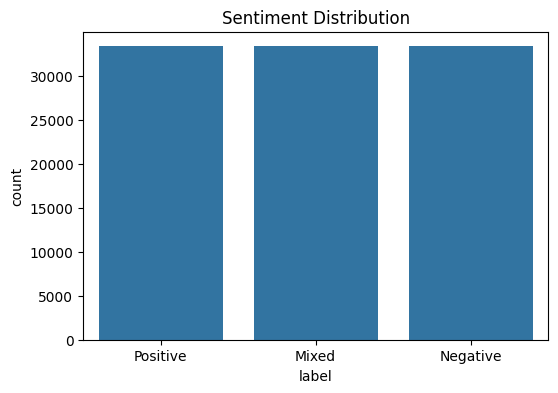

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")

plt.show()

# Arabic Text Preprocessing

In [8]:
import pandas as pd
import re
import string
import nltk
import emoji

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from pyarabic.araby import strip_tashkeel

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
arabic_stopwords = set(stopwords.words('arabic'))

#Arabic Normalization Function

In [10]:
def normalize_arabic(text):

    # Remove tashkeel
    text = strip_tashkeel(text)

    # Normalize letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    return text

#Remove Emojies

In [11]:
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

#Remove Punctuation & Special Characters

In [12]:
arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
all_punctuations = string.punctuation + arabic_punctuations

In [13]:
def remove_punctuation(text):
    translator = str.maketrans('', '', all_punctuations)
    return text.translate(translator)

#Remove Numbers & English Characters

In [14]:
def remove_non_arabic(text):
    text = re.sub(r'[A-Za-z]', '', text)
    text = re.sub(r'[0-9]', '', text)
    return text

#Tokenization + Stopword Removal

In [15]:
def tokenize_and_remove_stopwords(text):

    tokens = word_tokenize(text)

    filtered_tokens = [
        word for word in tokens
        if word not in arabic_stopwords and len(word) > 1
    ]

    return filtered_tokens

#Full Preprocessing Pipeline

In [16]:
def preprocess_text(text):

    # Normalize
    text = normalize_arabic(text)

    # Remove emojis
    text = remove_emojis(text)

    # Remove punctuation
    text = remove_punctuation(text)

    # Remove English & numbers
    text = remove_non_arabic(text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize + remove stopwords
    tokens = tokenize_and_remove_stopwords(text)

    return " ".join(tokens)

#Apply Preprocessing On Dataset

In [17]:
df['clean_text'] = df['text'].apply(preprocess_text)

Check Results

In [18]:
df[['text', 'clean_text']].head()

,text,clean_text
0,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوعا النظافه والموقع والتجهيز والشاطيء ا...
1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,احد اسباب نجاح الامارات ان شخص الدوله يعشق ترا...
2,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادفه وقويه تنقلك صخب شوارع القاهره الي هدوء ج...
3,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خلصنا مبدييا اللي مستني ابهار زي الفيل الازرق ...
4,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء يتجزا دبي فندق متكامل الخدمات...


#Save Clean Dataset

#Stemming & Lemmatization

import Stemmer (ISRIStemmer)

In [ ]:
from nltk.stem.isri import ISRIStemmer

Initialize Stemmer

In [ ]:
stemmer = ISRIStemmer()

**Create Stemming Function**

We will stem token by token.

In [ ]:
def stem_text(text):

    tokens = text.split()

    stemmed_tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    return " ".join(stemmed_tokens)

**Apply Stemming**

Use the already cleaned text

In [ ]:
df['stemmed_text'] = df['clean_text'].apply(stem_text)

Check Result

In [ ]:
df[['clean_text', 'stemmed_text']].head()

,clean_text,stemmed_text
0,ممتاز نوعا النظافه والموقع والتجهيز والشاطيء ا...,متز نوع نظف وقع جهز شاطيء طعم
1,احد اسباب نجاح الامارات ان شخص الدوله يعشق ترا...,احد سبب نجح امر ان شخص دول عشق ترب نحب امر ومض...
2,هادفه وقويه تنقلك صخب شوارع القاهره الي هدوء ج...,هدف وقي نقل صخب شرع قهر الي هدء جبل شيش عرف عل...
3,خلصنا مبدييا اللي مستني ابهار زي الفيل الازرق ...,خلص بدي الل مست بهر زي فيل زرق ميقراش احس حمد ...
4,ياسات جلوريا جزء يتجزا دبي فندق متكامل الخدمات...,ياس جلر جزء تجز دبي ندق كامل خدم ريح نفس وجد


#CAMeL Tools Lemmatization

In [19]:
!camel_data -i disambig-mle-calima-msa-r13

The following packages will be installed: 'disambig-mle-calima-msa-r13'
Extracting package 'disambig-mle-calima-msa-r13': 100% 88.7M/88.7M [00:00<00:00, 487MB/s]


In [20]:
from camel_tools.disambig.mle import MLEDisambiguator

In [21]:
mle = MLEDisambiguator.pretrained()

#Lemmatization Function

In [ ]:
def lemmatize_text(text):

    tokens = text.split()

    lemmas = []

    for token in tokens:

        disambig = mle.disambiguate([token])

        lemma = disambig[0].analyses[0].analysis['lex']

        lemmas.append(lemma)

    return " ".join(lemmas)

Apply Lemmatization & Apply Lemmatization

In [ ]:
df['lemmatized_text'] = df['clean_text'].apply(lemmatize_text)

In [ ]:
df[['clean_text', 'stemmed_text', 'lemmatized_text']].head()

,clean_text,stemmed_text,lemmatized_text
0,ممتاز نوعا النظافه والموقع والتجهيز والشاطيء ا...,متز نوع نظف وقع جهز شاطيء طعم,مُمْتاز نَوْع نَظافَة مَوْقِع تَجْهِيز والشاطي...
1,احد اسباب نجاح الامارات ان شخص الدوله يعشق ترا...,احد سبب نجح امر ان شخص دول عشق ترب نحب امر ومض...,أَحَد سَبَب نَجاح أَمارَة أَنَّ شَخْص دَوْلَة ...
2,هادفه وقويه تنقلك صخب شوارع القاهره الي هدوء ج...,هدف وقي نقل صخب شرع قهر الي هدء جبل شيش عرف عل...,هادِف قَوِيّ نَقَل صَخَب شارِع قاهِرَة إِلَى ه...
3,خلصنا مبدييا اللي مستني ابهار زي الفيل الازرق ...,خلص بدي الل مست بهر زي فيل زرق ميقراش احس حمد ...,خَلَص مبدييا لَيّ مَسّ ابهار زِيّ فِيل أَزْرَق...
4,ياسات جلوريا جزء يتجزا دبي فندق متكامل الخدمات...,ياس جلر جزء تجز دبي ندق كامل خدم ريح نفس وجد,ياسات جلوريا جُزْء تَجَزَّأ دُبَيّ فُنْدُق مُت...


# POS Tagging Function

In [ ]:
def pos_tag_text(text):

    tokens = text.split()

    tagged_tokens = []

    disambig = mle.disambiguate(tokens)

    for word in disambig:

        token = word.word

        try:
            pos = word.analyses[0].analysis['pos']
        except:
            pos = 'UNK'

        tagged_tokens.append((token, pos))

    return tagged_tokens

In [ ]:
sample_text = df['clean_text'].iloc[0]

pos_tag_text(sample_text)

[('ممتاز', 'adj'),
 ('نوعا', 'noun'),
 ('النظافه', 'noun'),
 ('والموقع', 'noun'),
 ('والتجهيز', 'noun'),
 ('والشاطيء', 'noun_prop'),
 ('المطعم', 'noun')]

#Store POS Tags in Dataset

In [ ]:
df['pos_tags'] = df['clean_text'].apply(pos_tag_text)

AttributeError: 'float' object has no attribute 'split'

In [ ]:
df.columns

Index(['label', 'text', 'clean_text', 'named_entities', 'has_person',
       'has_location', 'has_organization', 'lemmatized_text', 'adj_count',
       'adv_count'],
      dtype='object')

#Extract Important POS Features
We care mostly about:

adjectives (adj)

adverbs (adv)

because they are sentiment-heavy.

In [ ]:
def count_sentiment_pos(pos_tags):

    adj_count = 0
    adv_count = 0

    for token, pos in pos_tags:

        if pos == 'adj':
            adj_count += 1

        elif pos == 'adv':
            adv_count += 1

    return adj_count, adv_count

#Create POS Feature Columns

In [ ]:
df[['adj_count', 'adv_count']] = df['pos_tags'].apply(
    lambda x: pd.Series(count_sentiment_pos(x))
)

#Save Result

In [ ]:
df[['clean_text', 'adj_count', 'adv_count']].head()

,clean_text,adj_count,adv_count
0,ممتاز نوعا النظافه والموقع والتجهيز والشاطيء ا...,1,0
1,احد اسباب نجاح الامارات ان شخص الدوله يعشق ترا...,2,0
2,هادفه وقويه تنقلك صخب شوارع القاهره الي هدوء ج...,5,0
3,خلصنا مبدييا اللي مستني ابهار زي الفيل الازرق ...,7,0
4,ياسات جلوريا جزء يتجزا دبي فندق متكامل الخدمات...,3,0


#Named Entity Recognition (NER)

In [ ]:
from camel_tools.ner import NERecognizer

Load Pretrained Arabic NER Model

In [ ]:
# Download the specific NER data package needed for the pretrained model
!camel_data -i ner-arabert

# Initialize the recognizer
ner = NERecognizer.pretrained()

No new packages will be installed.


Some weights of the model checkpoint at /root/.camel_tools/data/ner/arabert were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


#Create NER Function

In [ ]:
def extract_ner(text):

    tokens = text.split()

    ner_tags = ner.predict_sentence(tokens)

    entities = []

    for token, tag in zip(tokens, ner_tags):

        if tag != 'O':
            entities.append((token, tag))

    return entities

Test on Sample Text

In [ ]:
sample_text = "احب دبي وشركة مايكروسوفت"

extract_ner(sample_text)

[('دبي', 'B-LOC'), ('مايكروسوفت', 'B-ORG')]

**Apply NER to Dataset**

In [ ]:
df['named_entities'] = df['clean_text'].apply(extract_ner)

#Create NER Feature Flags

We now convert entities into ML features.

In [ ]:
def ner_features(entities):

    has_person = 0
    has_location = 0
    has_organization = 0

    for token, tag in entities:

        if 'PER' in tag:
            has_person = 1

        elif 'LOC' in tag:
            has_location = 1

        elif 'ORG' in tag:
            has_organization = 1

    return has_person, has_location, has_organization

#Add NER Features to Dataset

In [ ]:
df[['has_person', 'has_location', 'has_organization']] = (
    df['named_entities']
    .apply(lambda x: pd.Series(ner_features(x)))
)

#Final Save

In [ ]:
df.to_csv(
    "results/ar_reviews_final_features.tsv",
    sep='\t',
    index=False,
    encoding='utf-8-sig'
)

In [ ]:
df.head()

,label,text,clean_text,named_entities,has_person,has_location,has_organization
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوعا النظافه والموقع والتجهيز والشاطيء ا...,[],0,0,0
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,احد اسباب نجاح الامارات ان شخص الدوله يعشق ترا...,"[(الامارات, B-LOC), (الامارات, B-LOC)]",0,1,0
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادفه وقويه تنقلك صخب شوارع القاهره الي هدوء ج...,"[(القاهره, B-LOC), (الشيشان, B-LOC)]",0,1,0
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خلصنا مبدييا اللي مستني ابهار زي الفيل الازرق ...,"[(احمد, B-PERS), (مراد, I-PERS), (احمد, B-PERS...",1,1,0
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء يتجزا دبي فندق متكامل الخدمات...,"[(ياسات, B-MISC), (جلوريا, B-MISC), (دبي, B-LOC)]",0,1,0


#Save full NLP Dataset

it will contain:
original text

* clean text
* stemmed text
* lemmatized text
* pos_tags
* named_entities
* feature flags

Backup dataset used for inspection and debugging

In [ ]:
df.to_csv(
    "results/ar_reviews_full_nlp.tsv",
    sep='\t',
    index=False,
    encoding='utf-8-sig'
)

print("Full NLP dataset saved successfully!")

Full NLP dataset saved successfully!


#Create CLEAN ML-READY DATASET

In [ ]:
ml_df = df[
    [
        'label',
        'clean_text',
        'lemmatized_text',
        'adj_count',
        'adv_count',
        'has_person',
        'has_location',
        'has_organization'
    ]
]

In [ ]:
ml_df.to_csv(
    "results/ar_reviews_ml_ready.tsv",
    sep='\t',
    index=False,
    encoding='utf-8-sig'
)

#Load ML Dataset

In [22]:
ml_df = pd.read_csv(
    "results/ar_reviews_ml_ready.tsv",
    sep='\t',
    encoding='utf-8-sig'
)

ml_df.head()

,label,clean_text,lemmatized_text,adj_count,adv_count,has_person,has_location,has_organization
0,Positive,ممتاز نوعا النظافه والموقع والتجهيز والشاطيء ا...,مُمْتاز نَوْع نَظافَة مَوْقِع تَجْهِيز والشاطي...,1,0,0,0,0
1,Positive,احد اسباب نجاح الامارات ان شخص الدوله يعشق ترا...,أَحَد سَبَب نَجاح أَمارَة أَنَّ شَخْص دَوْلَة ...,2,0,0,1,0
2,Positive,هادفه وقويه تنقلك صخب شوارع القاهره الي هدوء ج...,هادِف قَوِيّ نَقَل صَخَب شارِع قاهِرَة إِلَى ه...,5,0,0,1,0
3,Positive,خلصنا مبدييا اللي مستني ابهار زي الفيل الازرق ...,خَلَص مبدييا لَيّ مَسّ ابهار زِيّ فِيل أَزْرَق...,7,0,1,1,0
4,Positive,ياسات جلوريا جزء يتجزا دبي فندق متكامل الخدمات...,ياسات جلوريا جُزْء تَجَزَّأ دُبَيّ فُنْدُق مُت...,3,0,0,1,0


#Encode Labels

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

ml_df['label_encoded'] = label_encoder.fit_transform(ml_df['label'])

ml_df[['label', 'label_encoded']].head()

,label,label_encoded
0,Positive,2
1,Positive,2
2,Positive,2
3,Positive,2
4,Positive,2


#TF-IDF Feature Extraction
Convert Arabic text into numerical vectors.

Use:

* lemmatized text
* Arabic-friendly TF-IDF

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

# Fill NaN values in 'lemmatized_text' with empty strings
ml_df['lemmatized_text'] = ml_df['lemmatized_text'].fillna('')

X_tfidf = tfidf.fit_transform(
    ml_df['lemmatized_text']
)

X_tfidf.shape

(99999, 5000)

This creates:

* unigram + bigram features
* sparse matrix
* top 5000 most useful features

#Create POS + NER Numeric Features

In [25]:
extra_features = ml_df[
    [
        'adj_count',
        'adv_count',
        'has_person',
        'has_location',
        'has_organization'
    ]
]

Convert them to numeric matrix:

In [26]:
from scipy.sparse import csr_matrix

X_extra = csr_matrix(extra_features.values)

#Combine TF-IDF + POS + NER



In [27]:
from scipy.sparse import hstack

X = hstack([X_tfidf, X_extra])

y = ml_df['label_encoded']

check dimensions

In [28]:
print(X.shape)
print(y.shape)

(99999, 5005)
(99999,)


#Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Import ML Models

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

#Import Evaluation Metrics

In [31]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

#Train Naive Bayes

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

#Predict & Evaluate Naive Bayes

In [33]:
y_pred_nb = nb_model.predict(X_test)

**Accuracy**

In [34]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.53105


**F1 Score**

In [35]:
f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='macro'
)

print("Naive Bayes Macro F1:", f1_nb)

Naive Bayes Macro F1: 0.5312490228944015


**Full Classification Report**

In [36]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

           0       0.45      0.45      0.45      6666
           1       0.56      0.59      0.58      6667
           2       0.59      0.55      0.57      6667

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.53     20000
weighted avg       0.53      0.53      0.53     20000



**Confusion Matrix**

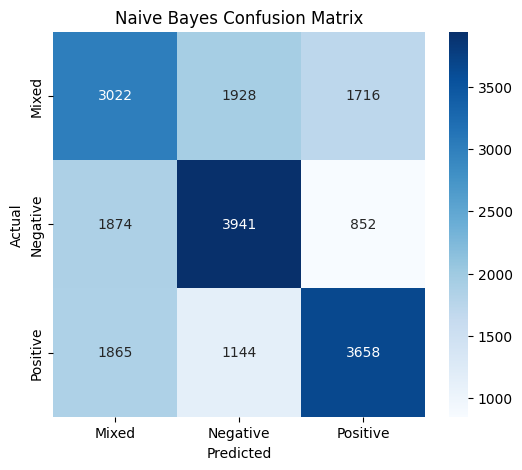

In [37]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Train Logistic Regression

In [ ]:
lr_model = LogisticRegression(
    max_iter=2000
)

lr_model.fit(X_train, y_train)

**Predict**

In [39]:
y_pred_lr = lr_model.predict(X_test)

**Accuracy**

In [40]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Macro F1:", accuracy_lr)

Logistic Regression Macro F1: 0.5467


**F1 Score**

In [41]:
f1_lr = f1_score(
        y_test,
        y_pred_lr,
        average='macro'
    )
print("Logistic Regression Macro F1:", f1_lr)

Logistic Regression Macro F1: 0.5472253915946571


**Full Classification Report**

In [42]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.47      0.48      0.47      6666
           1       0.58      0.59      0.58      6667
           2       0.60      0.57      0.59      6667

    accuracy                           0.55     20000
   macro avg       0.55      0.55      0.55     20000
weighted avg       0.55      0.55      0.55     20000



**Confusion Matrix**

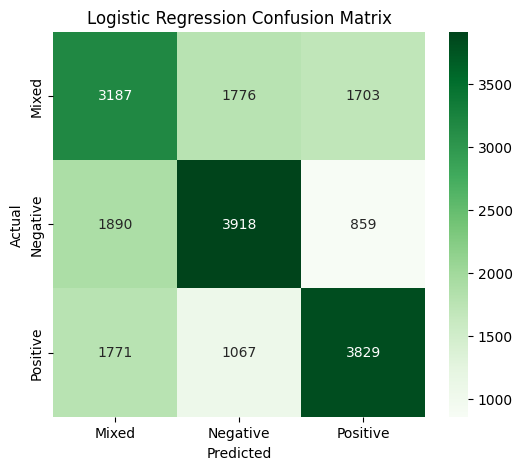

In [43]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Train SVM

In [ ]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

**Predict**

In [45]:
y_pred_svm = svm_model.predict(X_test)

**Accuracy**

In [46]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.5421


**F1 Score**

In [47]:
f1_svm =  f1_score(
        y_test,
        y_pred_svm,
        average='macro'
    )

print( "SVM Macro F1:", f1_svm)

SVM Macro F1: 0.5420266677184177


**Classification report:**

In [48]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.47      0.46      0.46      6666
           1       0.57      0.59      0.58      6667
           2       0.59      0.58      0.58      6667

    accuracy                           0.54     20000
   macro avg       0.54      0.54      0.54     20000
weighted avg       0.54      0.54      0.54     20000



**Confusion Matrix**

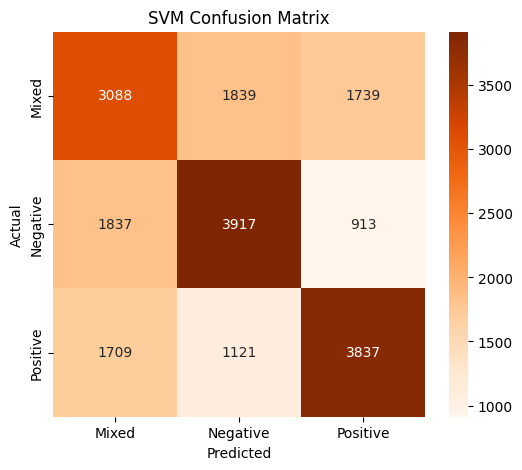

In [49]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison Graph

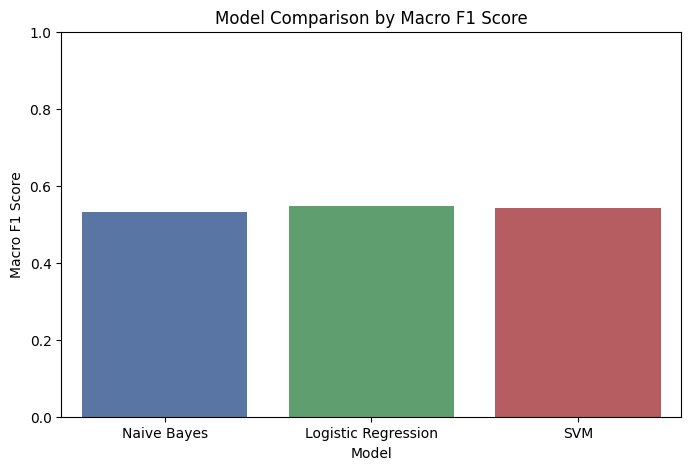

In [50]:
results = {
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Macro_F1': [
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro')
    ]
}

results_df = pd.DataFrame(results)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Macro_F1',
    data=results_df,
    palette=['#4C72B0', '#55A868', '#C44E52']
)

plt.title("Model Comparison by Macro F1 Score")
plt.ylabel("Macro F1 Score")
plt.ylim(0,1)

plt.show()

#CAMeL-BERT + GPT-4o Comparison

In [51]:
!pip install -q transformers datasets accelerate

In [52]:
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

#Train/Test Split

For transformers we use raw text directly.

Train it on sample from the dataset 50k and epochs = 5


In [53]:
sampled_df = ml_df.sample(
    n=50000,
    random_state=42
)

In [55]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    sampled_df['clean_text'],
    sampled_df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=sampled_df['label_encoded']
)

In [56]:
print("Total samples:", len(sampled_df))
print("Train samples:", len(train_texts))
print("Test samples:", len(test_texts))

Total samples: 50000
Train samples: 40000
Test samples: 10000


# Load CAMel-BERT

In [57]:
model_name = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"

**Tokenizer**

In [58]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

**Model:**

In [59]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

# Tokenization

This converts Arabic text into transformer tokens.

In [61]:
print(train_texts.head())
print(train_texts.dtype)

print(train_texts.isna().sum())

35538                          فكره ممتازه السرد جزء الملل
6139     افضل قرات افضل ساقرا اقول اجمل قرات لانها كانت...
46626    مقبول الموقع والبهو والنادي الرياضي ارتفاع سعر...
34280    كتاب لطيف يبدو ان الترجمه افسدته رحله باس القر...
35839    الرويه اقرب الي فيلم سينمايي مفيش فن ادبي يجذب...
Name: clean_text, dtype: object
object
9


In [63]:
non_strings = train_texts[~train_texts.apply(lambda x: isinstance(x, str))]
print(len(non_strings))
print(non_strings.head())

9
25193    NaN
27432    NaN
81087    NaN
21558    NaN
51456    NaN
Name: clean_text, dtype: object


we have 9 missing values in clean_text so we fill them with empty strings


In [64]:
train_texts = train_texts.fillna("").astype(str)
test_texts = test_texts.fillna("").astype(str)

In [65]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

# Create Dataset

In [66]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': list(test_labels)
})

# Define Metrics

In [67]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(
        labels,
        predictions,
        average='macro'
    )

    return {
        'accuracy': accuracy,
        'f1': f1
    }

#Training Configuration

In [68]:
training_args = TrainingArguments(
    output_dir="./camelbert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_dir='./logs',

    load_best_model_at_end=True
)

#Trainer

In [69]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

#Train CAMeL-BERT

In [70]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: WARNING Invalid choice


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.699100,0.681144,0.699100,0.697296
2,0.571700,0.727646,0.697400,0.696707
3,0.392500,1.013654,0.693200,0.696116
4,0.275500,1.641650,0.694000,0.694760
5,0.174900,1.829293,0.689800,0.691558


TrainOutput(global_step=25000, training_loss=0.4301594030761719, metrics={'train_runtime': 5821.1896, 'train_samples_per_second': 34.357, 'train_steps_per_second': 4.295, 'total_flos': 1.31556708864e+16, 'train_loss': 0.4301594030761719, 'epoch': 5.0})

#SAVE MODEL

In [71]:
trainer.save_model("results/camelbert_model")

tokenizer.save_pretrained(
    "results/camelbert_model"
)

('results/camelbert_model/tokenizer_config.json',
 'results/camelbert_model/special_tokens_map.json',
 'results/camelbert_model/vocab.txt',
 'results/camelbert_model/added_tokens.json',
 'results/camelbert_model/tokenizer.json')

#Evaluate CAMeL-BERT

In [72]:
results = trainer.evaluate()
camelbert_f1 = results["eval_f1"]
camelbert_acc = results["eval_accuracy"]

print(results)

{'eval_loss': 0.6811443567276001, 'eval_accuracy': 0.6991, 'eval_f1': 0.6972958559531618, 'eval_runtime': 77.6367, 'eval_samples_per_second': 128.805, 'eval_steps_per_second': 16.101, 'epoch': 5.0}


#Generate Predictions

In [74]:
  import numpy as np

pred_output = trainer.predict(test_dataset)

y_pred = np.argmax(pred_output.predictions, axis=1)

y_true = pred_output.label_ids

# Classification Report

In [75]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Mixed       0.62      0.57      0.60      3367
    Negative       0.74      0.79      0.76      3327
    Positive       0.73      0.74      0.74      3306

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



# Confusion Matrix Visualization

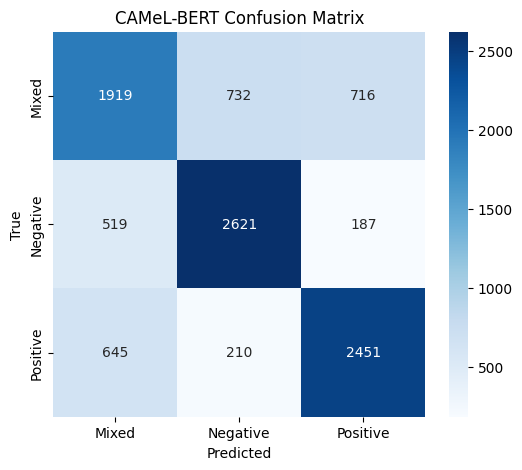

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CAMeL-BERT Confusion Matrix")

plt.show()

# Create Predictions DataFrame


In [77]:
import pandas as pd

camelbert_results_df = pd.DataFrame({
    "text": list(test_texts),
    "true_label": y_true,
    "camelbert_prediction": y_pred
})

camelbert_results_df.head()

,text,true_label,camelbert_prediction
0,ضعيف جدا المكان جميل السعر مناسب المواقف السيا...,1,1
1,احلام مستغانمي باسلوبها الاخاذ الساحر اسلوبها ...,0,2
2,ضعيف جدا سي جدا والخدمه سييه جدا,1,1
3,ولدي انتم تثورون علي ظالم لتاتوا باشد ظلما ترا...,2,2
4,قررت قراءه الروايه ان رايت كميه المدح تدور قصه...,1,1


# Error Analysis
This gives:
* incorrectly classified tweets
* material for discussion section
* “why transformer failed” analysis

In [78]:
errors = camelbert_results_df[
    camelbert_results_df["true_label"]
    != camelbert_results_df["camelbert_prediction"]
]

errors.head(10)

,text,true_label,camelbert_prediction
1,احلام مستغانمي باسلوبها الاخاذ الساحر اسلوبها ...,0,2
9,يسمو بالنفس للارتقاء التعامل الاختلافات بالراي,2,0
16,اعتقد انها اجمل نصها الفرنسي,0,1
25,الريفيو التاني لايزال الملل بتاع المره الاولي ...,1,0
27,فندق رايع المالك وابنه كانا فظيعين شهر قمت بحج...,0,2
29,كتاب مهم يحكي شييا فصول الاصلاح السعوديه وتاري...,2,0
33,مكان جميل قريب مول الامارات,0,2
34,الروايه دي اخدت دعايه جامده جدا احداث كتير متو...,1,2
35,الاس الاستقبال جيد الفندق يستحق الاسم دورات ال...,1,0
36,حكايات مفهاش اي حبكه او حكمه مواقف حصلتله وبيح...,0,1


#Final Metrics Print

In [79]:
print("CAMeL-BERT FINAL RESULTS")
print("-------------------------")
print("Accuracy:", camelbert_acc)
print("Macro F1:", camelbert_f1)

CAMeL-BERT FINAL RESULTS
-------------------------
Accuracy: 0.6991
Macro F1: 0.6972958559531618


# Save Metrics for Comparison

In [80]:
camelbert_metrics = {
    "model": "CAMeL-BERT",
    "accuracy": camelbert_acc,
    "f1": camelbert_f1
}

print(camelbert_metrics)

{'model': 'CAMeL-BERT', 'accuracy': 0.6991, 'f1': 0.6972958559531618}


# GPT-4o FEW-SHOT COMPARISON

In [81]:
!pip install -q openai

In [82]:
import os
from openai import OpenAI

# Create OpenAI Client

In [83]:
client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"]
)

# Create Small Evaluation Sample

In [84]:
sample_size = 150

sample_df = ml_df.sample(
    sample_size,
    random_state=42
)

gpt_texts = list(sample_df['clean_text'])

gpt_true = list(sample_df['label_encoded'])

# Build GPT Few-Shot Prompt Function

In [87]:
def classify_with_gpt(text):

    prompt = f"""
أنت خبير في تحليل المشاعر للنصوص العربية.

صنّف النص التالي إلى فئة واحدة فقط من الفئات التالية:

- Positive
- Negative
- Mixed

أمثلة:

النص: هذا المنتج رائع جداً وأنصح به الجميع
التصنيف: Positive

النص: الخدمة سيئة للغاية ولن أتعامل معهم مرة أخرى
التصنيف: Negative

النص: يوجد بعض المميزات ولكن توجد أيضاً عيوب واضحة
التصنيف: Mixed

الآن قم بتصنيف النص التالي:

النص:
{text}

أعد فقط اسم الفئة بدون أي شرح إضافي.
"""

    response = client.chat.completions.create(
        model="gpt-5.5",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content.strip()

**Run GPT Predictions**

In [88]:
gpt_predictions = []

for i, text in enumerate(gpt_texts):

    prediction = classify_with_gpt(text)

    gpt_predictions.append(prediction)

    print(f"{i+1}/{sample_size} -> {prediction}")

1/150 -> Mixed
2/150 -> Positive
3/150 -> Mixed
4/150 -> Negative
5/150 -> Mixed
6/150 -> Mixed
7/150 -> Mixed
8/150 -> Negative
9/150 -> Negative
10/150 -> Mixed
11/150 -> Mixed
12/150 -> Mixed
13/150 -> Mixed
14/150 -> Positive
15/150 -> Positive
16/150 -> Negative
17/150 -> Negative
18/150 -> Positive
19/150 -> Negative
20/150 -> Negative
21/150 -> Negative
22/150 -> Positive
23/150 -> Mixed
24/150 -> Positive
25/150 -> Positive
26/150 -> Mixed
27/150 -> Mixed
28/150 -> Negative
29/150 -> Mixed
30/150 -> Mixed
31/150 -> Mixed
32/150 -> Mixed
33/150 -> Positive
34/150 -> Negative
35/150 -> Mixed
36/150 -> Negative
37/150 -> Negative
38/150 -> Mixed
39/150 -> Positive
40/150 -> Positive
41/150 -> Positive
42/150 -> Negative
43/150 -> Mixed
44/150 -> Positive
45/150 -> Mixed
46/150 -> Mixed
47/150 -> Mixed
48/150 -> Mixed
49/150 -> Positive
50/150 -> Mixed
51/150 -> Mixed
52/150 -> Mixed
53/150 -> Positive
54/150 -> Mixed
55/150 -> Negative
56/150 -> Mixed
57/150 -> Negative
58/150 -> 

# Clean GPT Labels

In [89]:
gpt_predictions = [
    pred.strip().capitalize()
    for pred in gpt_predictions
]

## Convert GPT Labels → Numbers

In [90]:
cleaned_predictions = []

for pred in gpt_predictions:

    pred = pred.lower().strip()

    if "positive" in pred:
        cleaned_predictions.append("Positive")

    elif "negative" in pred:
        cleaned_predictions.append("Negative")

    elif "mixed" in pred:
        cleaned_predictions.append("Mixed")

    else:
        cleaned_predictions.append("Mixed")

In [91]:
gpt_pred_encoded = label_encoder.transform(cleaned_predictions)

# Evaluate GPT-4o

In [92]:
from sklearn.metrics import classification_report

print(classification_report(
    gpt_true,
    gpt_pred_encoded,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Mixed       0.45      0.59      0.51        51
    Negative       0.72      0.60      0.65        52
    Positive       0.66      0.57      0.61        47

    accuracy                           0.59       150
   macro avg       0.61      0.59      0.59       150
weighted avg       0.61      0.59      0.59       150



### Compute GPT Metrics

In [93]:
gpt_accuracy = accuracy_score(
    gpt_true,
    gpt_pred_encoded
)

gpt_f1 = f1_score(
    gpt_true,
    gpt_pred_encoded,
    average='macro'
)

print("GPT-5.5 Accuracy:", gpt_accuracy)
print("GPT-5.5 F1:", gpt_f1)

GPT-5.5 Accuracy: 0.5866666666666667
GPT-5.5 F1: 0.5930294851347483


# GPT Confusion Matrix

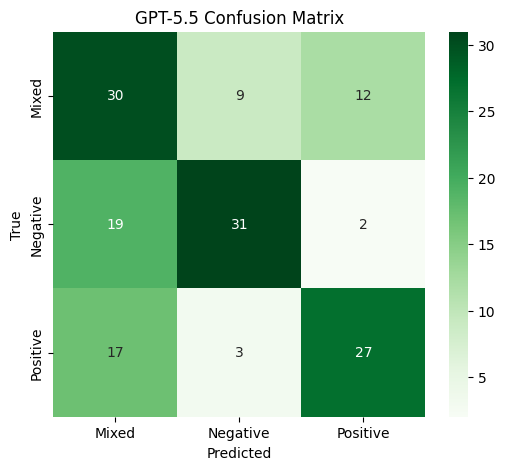

In [95]:
cm_gpt = confusion_matrix(
    gpt_true,
    gpt_pred_encoded
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gpt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("GPT-5.5 Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# Gather ALL Metrics

In [96]:
comparison_df = pd.DataFrame({
    "Model": [
        "SVM",
        "Logistic Regression",
        "Naive Bayes",
        "CAMeL-BERT",
        "GPT-5.5"
    ],

    "Accuracy": [
        accuracy_svm,
        accuracy_lr,
        accuracy_nb,
        camelbert_acc,
        gpt_accuracy
    ],

    "F1 Score": [
        f1_svm,
        f1_lr,
        f1_nb,
        camelbert_f1,
        gpt_f1
    ]
})

comparison_df

,Model,Accuracy,F1 Score
0,SVM,0.542100,0.542027
1,Logistic Regression,0.546700,0.547225
2,Naive Bayes,0.531050,0.531249
3,CAMeL-BERT,0.699100,0.697296
4,GPT-5.5,0.586667,0.593029


# Final Model Comparison Graph

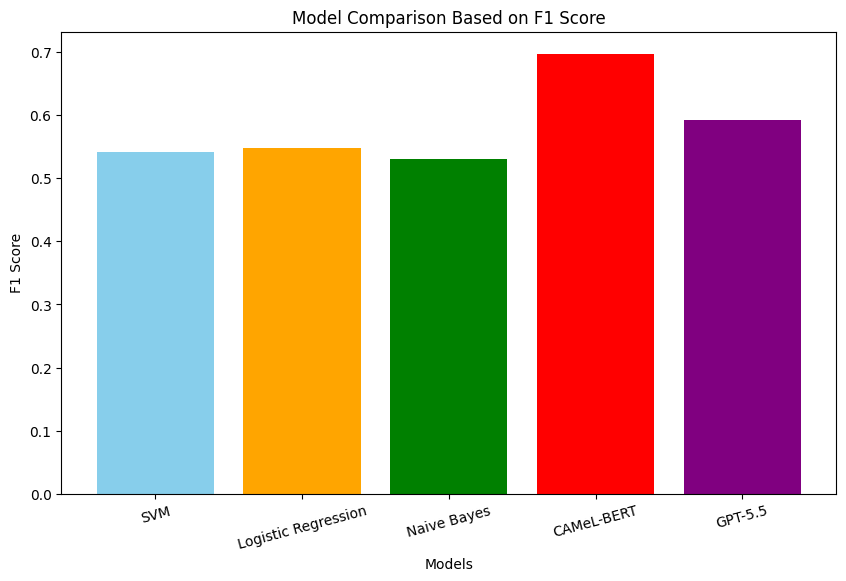

In [97]:
colors = [
    "skyblue",
    "orange",
    "green",
    "red",
    "purple"
]

plt.figure(figsize=(10,6))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"],
    color=colors
)

plt.title("Model Comparison Based on F1 Score")

plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()